# 03 · Finding complaint themes with NLP and clustering

In notebook 01 I labelled themes with hand-written keyword rules. Here I ask a different question:
**if the machine groups complaints on its own, without my rules, what groups does it find?**

Method (unsupervised learning, lessons 14–20 of ML-For-Beginners):
1. Clean the text and remove words that carry no meaning here (bank names, "complains", "Mr"…)
2. Turn each complaint into numbers with **TF-IDF**
3. Group similar complaints with **K-Means clustering**
4. Choose the number of clusters with the **silhouette score**
5. Read the top words per cluster and compare with the rule-based themes

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make "src" importable when the notebook runs from the notebooks/ folder
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.max_colwidth", 120)

In [2]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv(ROOT / "data" / "processed" / "decisions_clean.csv")
df["complaint_text"].head(3).tolist()

['Mr C complains that J.P. Morgan Europe Limited trading as Chase didn’t do enough to help him when he told it about a dispute he had with a merchant over goods paid for using his Chase debit card.',
 'Miss C complains that Creation Consumer Finance Ltd lent irresponsibly to her. She’s said the hire purchase agreement took up a substantial proportion of her income',
 'Mrs A complains that FirstRand Bank Limited trading as MotoNovo Finance was irresponsible to have agreed car finance for her in 2014.']

## 1. Stop words specific to this data
Every complaint starts like *"Mr X complains that Barclays Bank UK PLC…"*. Those words appear everywhere, so they would dominate the clusters.
I build a custom stop-word list from (a) standard English stop words, (b) every word in every business name, and (c) Ombudsman boilerplate.

In [3]:
business_words = set()
for name in pd.concat([df["business"], df["business_clean"], df["firm_group"]]).unique():
    business_words |= set(re.findall(r"[a-z]+", name.lower()))

boilerplate = {"mr", "mrs", "miss", "ms", "complain", "complains", "complained", "complaint", "complaining",
               "unhappy", "says", "said", "say", "trading", "known", "refer", "ll", "ve", "don", "didn", "won", "hasn",
               "haven", "wasn", "isn", "t", "s", "d", "company", "limited", "ltd", "plc", "uk", "bank", "lender",
               "estate", "late", "director", "represented", "representative", "behalf", "halifax", "tesco", "chase",
               "novuna", "alphera", "aqua", "marbles", "zable", "autolend", "updraft", "oplo", "tide", "virgin", "money",
               "first", "direct", "barclaycard", "vauxhall", "mini", "skoda", "audi", "mg", "mobilize", "essence", "amended"}
stop_words = list(ENGLISH_STOP_WORDS | business_words | boilerplate)
print(len(stop_words), "stop words")

617 stop words


## 2. TF-IDF
TF-IDF gives each word a weight: high if it's frequent **in this complaint** but rare **across all complaints**.
I also include two-word phrases (`ngram_range=(1, 2)`) so "hire purchase" or "credit file" stay together.

In [4]:
def normalise(text):
    text = text.lower().replace("’", "'")
    return re.sub(r"[^a-z\s]", " ", text)

vectorizer = TfidfVectorizer(preprocessor=normalise, stop_words=stop_words, ngram_range=(1, 2),
                             min_df=4, max_df=0.4, sublinear_tf=True)
X = vectorizer.fit_transform(df["complaint_text"])
terms = np.array(vectorizer.get_feature_names_out())
print("Matrix shape (complaints × terms):", X.shape)

Matrix shape (complaints × terms): (960, 434)


## 3. How many clusters? Silhouette score
The silhouette score (−1 to 1) measures how well each complaint sits inside its own cluster versus the next one. Higher is better. Text data usually scores low (0.02–0.1 is normal), so I look for the best value rather than a high absolute value.

I only test 6–12 clusters: fewer would merge obviously different topics, and more than ~12 becomes too many to explain to a business audience. With text data the score often keeps creeping up as k grows, so I take the best value **within** that sensible range.

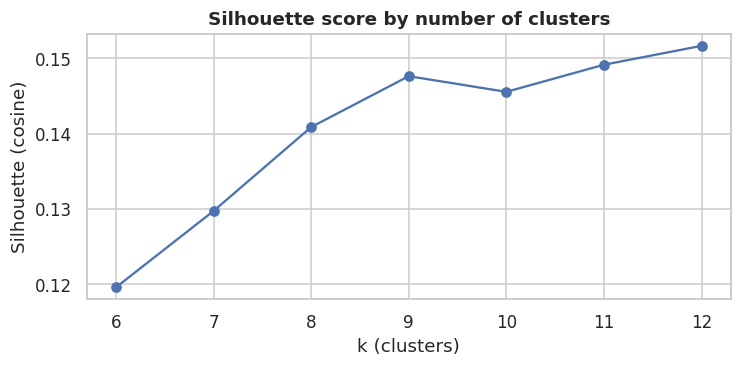

Best k: 12


In [5]:
scores = {}
for k in range(6, 13):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    scores[k] = silhouette_score(X, km.fit_predict(X), metric="cosine")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(list(scores), list(scores.values()), marker="o")
ax.set(title="Silhouette score by number of clusters", xlabel="k (clusters)", ylabel="Silhouette (cosine)")
plt.tight_layout(); plt.savefig(FIG_DIR / "05_silhouette.png"); plt.show()
best_k = max(scores, key=scores.get)
print("Best k:", best_k)

## 4. Fit K-Means and read each cluster's top words

In [6]:
km = KMeans(n_clusters=best_k, n_init=20, random_state=42)
df["cluster"] = km.fit_predict(X)

top_terms = {}
for c in range(best_k):
    centre = km.cluster_centers_[c]
    top_terms[c] = ", ".join(terms[centre.argsort()[::-1][:8]])

summary = (df.groupby("cluster").agg(size=("reference", "size"), upheld_rate=("upheld", "mean"),
                                     main_rule_theme=("theme", lambda s: s.value_counts().index[0]),
                                     purity=("theme", lambda s: s.value_counts(normalize=True).iloc[0]))
             .assign(top_words=pd.Series(top_terms)))
summary.style.format({"upheld_rate": "{:.0%}", "purity": "{:.0%}"})

,size,upheld_rate,main_rule_theme,purity,top_words
cluster,,,,,
0,51,14%,Irresponsible lending,100%,"irresponsibly, lent, irresponsibly lent, lent irresponsibly, acted irresponsibly, approved, acted, irresponsibly approved"
1,50,12%,Timeshare / unfair credit (s140A),98%,"unfairly unreasonably, party unfair, unreasonably party, unreasonably, acted unfairly, unfair, party, relationship section"
2,91,57%,Car finance - vehicle quality,78%,"agreement, quality, hire, hire purchase, purchase agreement, purchase, supplied, supplied hire"
3,40,30%,Service & administration,57%,"loan, fixed sum, sum loan, sum, fixed, loan agreement, agreement, provided loan"
4,25,16%,Scam / APP fraud,100%,"victim, victim scam, lost victim, refund, refund lost, scam, lost, lost falling"
5,46,15%,Unauthorised transactions,80%,"transactions, authorise, refund transactions, refund, refused refund, transactions account, refused, account"
6,57,30%,Scam / APP fraud,100%,"fell victim, fell, victim, scam, lost fell, victim scam, lost, reimburse"
7,99,23%,Scam / APP fraud,96%,"scam, lost, refund, refund lost, lost scam, result, lost result, refund scam"
8,30,23%,Scam / APP fraud,90%,"falling victim, falling, scam, protect, victim, reported, reported falling, failed protect"


In [7]:
# One example complaint from each cluster
for c in range(best_k):
    ex = df.loc[df["cluster"] == c, "complaint_text"].sample(1, random_state=1).iloc[0]
    print(f"Cluster {c}: {ex[:140]}")

Cluster 0: Mr B complains Moneybarn No.1 Limited (Moneybarn) irresponsibly entered into a car finance agreement because it didn’t carry out reasonable 
Cluster 1: Mr H and Mrs P’s complaint is, in essence, that First Holiday Finance Ltd (the ‘Lender’) acted unfairly and unreasonably by (1) being party 
Cluster 2: Mr H complains about the quality of a vehicle he acquired through a hire purchase agreement financed by Startline Motor Finance Limited (SMF
Cluster 3: Mrs H has complained about the quality of a device she bought using a fixed sum loan agreement with EE Limited.
Cluster 4: Mrs K has complained that Lloyds Bank PLC won’t refund the money she lost after falling victim to a scam.
Cluster 5: Mr B has complained that Barclays Bank UK PLC has declined to refund payments he says he didn’t make.
Cluster 6: Mr N complains that Monzo Bank Ltd (‘Monzo’) won’t refund him the money he lost after he fell victim to a scam.
Cluster 7: Mr C is being represented by solicitors. He’s complaining

## 5. Do the clusters agree with my rules?
`purity` above is the share of each cluster that belongs to its most common rule-based theme. The heatmap shows the full overlap.

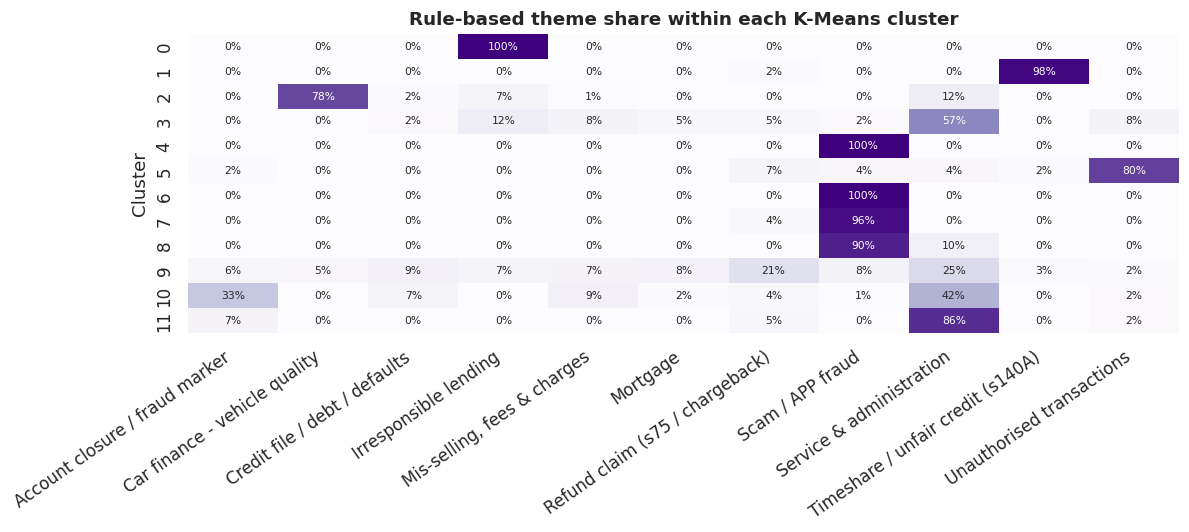

In [8]:
overlap = pd.crosstab(df["cluster"], df["theme"], normalize="index")
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(overlap, annot=True, fmt=".0%", cmap="Purples", cbar=False, annot_kws={"fontsize": 7}, ax=ax)
ax.set(title="Rule-based theme share within each K-Means cluster", xlabel="", ylabel="Cluster")
plt.xticks(rotation=35, ha="right"); plt.tight_layout()
plt.savefig(FIG_DIR / "06_clusters_vs_rules.png"); plt.show()

In [9]:
from sklearn.metrics import adjusted_rand_score
print(f"Adjusted Rand Index (0 = random, 1 = identical): {adjusted_rand_score(df['theme'], df['cluster']):.2f}")

Adjusted Rand Index (0 = random, 1 = identical): 0.21


In [10]:
df[["reference", "cluster"]].to_csv(ROOT / "data" / "processed" / "clusters.csv", index=False)

## What I learned
- K-Means **rediscovers the distinctive themes** (scams, car-finance quality, timeshare/s140A, irresponsible lending, unauthorised transactions, customer service): those clusters are 78–100% one rule-based theme. That gives me confidence the rule-based labels are sensible.
- **Scams split into several clusters** that differ in *wording* ("won't refund money he lost to a scam" vs "fell victim to an investment scam") rather than meaning. That's a known weakness of TF-IDF + K-Means: it groups by shared words, not shared meaning. Sentence embeddings would fix it.
- Account closures don't get a clean cluster of their own: they mix with other account-handling complaints ("closed", "blocked", "funds", "balance").
- One large, mixed cluster collects the **service/administration** complaints, which share vocabulary with everything else. That's also why the overall agreement score (Adjusted Rand Index ≈ 0.2) is modest.
- The input is only the opening sentence of each decision summary. With the full decision PDFs, the clusters would be much sharper.
- **Why keep the rules as the main labels?** They're explainable to a non-technical manager. Clustering is the check, not the replacement.